 ## Data Augmentation

 To improve the first training loop and  overfitting obtain in notebook 1 , and push validation accuracy three strategies are pursued:
- **ConvNeXt-Tiny Backbone:** Replaces ResNet18 with ConvNeXt-Tiny, a modernized convolutional architecture superior at extracting fine-grained visual details.
- **Manuscript-Specific Data Augmentation:** Incorporates `RandomResizedCrop`, subtle rotations ($\pm 8^\circ$), brightness/contrast adjustments (simulating parchment aging and varying lighting conditions), and `ColorJitter`.
- **Regularization & Optimization:** Utilizes `AdamW` ($\text{weight\_decay} = 10^{-2}$) alongside `LabelSmoothingCrossEntropy` loss to penalize overconfident predictions and improve network generalization.

### 1. Environment Setup and Dataset Mapping

In [ ]:
import os, glob
import pandas as pd
import torch
from PIL import Image, ImageFile

Image.MAX_IMAGE_PIXELS = None
ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")

# Paths
DATA_DIR = "/kaggle/input/datasets/mariajgamboa/clammdst/CLaMM_DST"
CSV_PATH = os.path.join(DATA_DIR, "CLaMM_Metadata.csv")

# Cargar CSV
df = pd.read_csv(CSV_PATH, sep=None, engine='python')
df.columns = df.columns.str.strip()

# New labels (1-12 a 0-11)
script_col = [col for col in df.columns if col.upper() == 'SCRIPT_TYPE'][0]
df['label'] = df[script_col].astype(int) - 1
num_classes = df['label'].nunique()

# Mapa de archivos 
all_image_paths = (
    glob.glob(f"{DATA_DIR}/**/*.[jJ][pP][gG]", recursive=True) +
    glob.glob(f"{DATA_DIR}/**/*.[pP][nN][gG]", recursive=True) +
    glob.glob(f"{DATA_DIR}/**/*.[tT][iI][fF]", recursive=True) +
    glob.glob(f"{DATA_DIR}/**/*.[jJ][pP][eE][gG]", recursive=True)
)
image_map = {os.path.basename(p).lower(): p for p in all_image_paths}

print(f"Dataset CLaMM_DST cargado exitosamente: {len(df)} registros | {num_classes} clases.")

Dispositivo activo: cpu
Dataset CLaMM_DST cargado exitosamente: 4540 registros | 12 clases.


### 2. PyTorch `CLaMMDataset` Class Definition

In [2]:
from torch.utils.data import Dataset

class CLaMMDataset(Dataset):
    def __init__(self, df, image_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_map = image_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = str(row['FILENAME']).strip().lower()

        if img_name in self.image_map:
            final_path = self.image_map[img_name]
        else:
            base_name = os.path.splitext(img_name)[0]
            matched = None
            for ext in ['.jpg', '.jpeg', '.tif', '.png']:
                if (base_name + ext) in self.image_map:
                    matched = self.image_map[base_name + ext]
                    break
            final_path = matched

        if not final_path:
            raise KeyError(f"No se encontró la imagen: '{row['FILENAME']}'")

        image = Image.open(final_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(row['label'], dtype=torch.long)

print("Clase CLaMMDataset configurada para Notebook 2.")

Clase CLaMMDataset configurada para Notebook 2.


### 3. Data Augmentation and DataLoaders
To solve the overfitting observed in Notebook 1 (99.8% Train Acc vs. 64.6% Val Acc), we try a new data regularization pipeline:
- **RandomResizedCrop (224x224, scale 0.8 to 1.0):** Simulates varying framing conditions and forces the model to focus on different calligraphic regions across the parchment.
- **RandomRotation ($\pm 8^\circ$):** Introduces realistic page tilt variations present in manuscript digitizations without distorting morphological ductus legibility.
- **ColorJitter (Brightness/Contrast 0.2, Saturation 0.1):** Simulates differences in lighting during capture, parchment aging, and ink density variation.
- **ImageNet Normalization:** Applies standard ImageNet parameters (`mean` and `std`) to the processed image tensors.
- **Reproducible Partitioning:** Maintains the identical random seed (`seed=42`) for `random_split` (3,632 Train / 908 Val) to ensure evaluation results remain directly comparable with the baseline model.

In [ ]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

#  Data Augmentation 
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomHorizontalFlip(p=0.2), # Ligero
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones de Validacion 
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = CLaMMDataset(df=df, image_map=image_map, transform=train_tf)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset.transform = val_tf

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"DataLoaders con Augmentation listos: {len(train_dataset)} Train | {len(val_dataset)} Val")

DataLoaders con Augmentation listos: 3632 Train | 908 Val


### 4. Fine-Tuning ConvNeXt-Tiny with Advanced Regularization
We replace ResNet18 architecture with **ConvNeXt-Tiny**, a modern convolutional neural network optimized for fine-grained visual classification:
- **Classifier Head Adaptation:** We modify the final linear layer (`model.classifier[2]`) to map features to our 12 medieval script target classes.
- **Label Smoothing Loss ($0.1$):** Softens ground-truth labels to prevent the model from assigning hyper-confident probabilities and memorizing background noise.
- **AdamW Optimizer ($\text{learning\_rate} = 10^{-4}$, $\text{weight\_decay} = 10^{-2}$):** Applies weight decay ($L_2$ regularization) directly to model parameters to constrain complexity and mitigate overfitting.
- **Cosine Annealing Scheduler:** Smoothly decays the learning rate following a cosine schedule across 15 epochs, facilitating optimal convergence toward stable local minima.

In [ ]:
import time
import torch.nn as nn
from torchvision import models

# ConvNeXt-Tiny Preentrenado
weights = models.ConvNeXt_Tiny_Weights.DEFAULT
model = models.convnext_tiny(weights=weights)

# Reemplazar clasificadora (classifier[2] en ConvNeXt)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, num_classes)
model = model.to(device)

#  Label Smoothing + Optimizador AdamW (con Weight Decay)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

num_epochs = 15
best_val_acc = 0.0

print("--- Inicio de Fine-Tuning con ConvNeXt-Tiny (4,540 imágenes) ---")
start_time = time.time()

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels.data)
        total_train += labels.size(0)

    scheduler.step()
    train_loss = running_loss / total_train
    train_acc = (correct_train.double() / total_train).item()

    # VAL
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data)
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val.double() / total_val).item()

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "convnext_tiny_clamm4540.pth")
        saved_mark = "[Guardado]"
    else:
        saved_mark = ""

    print(f"Época [{epoch+1:02d}/{num_epochs:02d}] | "
          f"Train Loss: {train_loss:.4f} - Acc: {train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc:.4f} {saved_mark}")

elapsed_time = (time.time() - start_time) / 60
print(f"\nEntrenamiento ConvNeXt-Tiny completado en {elapsed_time:.2f} minutos.")
print(f"Mejor Precisión de Validación Alcanzada: {best_val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:01<00:00, 107MB/s]


--- Inicio de Fine-Tuning con ConvNeXt-Tiny (4,540 imágenes) ---
Época [01/15] | Train Loss: 1.7436 - Acc: 0.4579 | Val Loss: 1.4689 - Acc: 0.5892 [Guardado]
Época [02/15] | Train Loss: 1.2692 - Acc: 0.6561 | Val Loss: 1.3163 - Acc: 0.6399 [Guardado]
Época [03/15] | Train Loss: 1.0583 - Acc: 0.7693 | Val Loss: 1.2731 - Acc: 0.6740 [Guardado]
Época [04/15] | Train Loss: 0.8289 - Acc: 0.8841 | Val Loss: 1.2631 - Acc: 0.6707 
Época [05/15] | Train Loss: 0.6900 - Acc: 0.9548 | Val Loss: 1.2919 - Acc: 0.6784 [Guardado]
Época [06/15] | Train Loss: 0.6150 - Acc: 0.9827 | Val Loss: 1.2693 - Acc: 0.7059 [Guardado]
Época [07/15] | Train Loss: 0.5783 - Acc: 0.9948 | Val Loss: 1.2673 - Acc: 0.7037 
Época [08/15] | Train Loss: 0.5644 - Acc: 0.9964 | Val Loss: 1.2889 - Acc: 0.7015 
Época [09/15] | Train Loss: 0.5595 - Acc: 0.9967 | Val Loss: 1.2874 - Acc: 0.7093 [Guardado]
Época [10/15] | Train Loss: 0.5531 - Acc: 0.9972 | Val Loss: 1.2754 - Acc: 0.7159 [Guardado]
Época [11/15] | Train Loss: 0.5489 

### 5. Evaluation: 
We evaluate the optimized model:
- **Checkpoint Restoration:** We load the saved weights (`convnext_tiny_clamm4540.pth`), which achieved the peak validation accuracy.
- **Per-Class Metrics:** We analyze the impact of *Data Augmentation* and the ConvNeXt architecture on *Precision*, *Recall*, and *F1-Score* across all 12 medieval script classes.
- **Confusion Matrix Inspection:** Plot: the misclassifications to compare

Evaluando el mejor modelo ConvNeXt-Tiny guardado en el conjunto de validación...

--- REPORTE DE CLASIFICACIÓN POR CLASE (ConvNeXt-Tiny) ---
              precision    recall  f1-score   support

      Tipo 1     0.8595    0.8667    0.8631       120
      Tipo 2     0.6271    0.6727    0.6491       110
      Tipo 3     0.9000    0.8780    0.8889        41
      Tipo 4     0.7833    0.8868    0.8319        53
      Tipo 5     0.8913    0.9318    0.9111        44
      Tipo 6     0.4533    0.4304    0.4416        79
      Tipo 7     0.7905    0.7757    0.7830       107
      Tipo 8     0.5556    0.4237    0.4808        59
      Tipo 9     0.4754    0.4143    0.4427        70
     Tipo 10     0.6429    0.6750    0.6585        40
     Tipo 11     0.7170    0.7755    0.7451       147
     Tipo 12     1.0000    0.9474    0.9730        38

    accuracy                         0.7159       908
   macro avg     0.7247    0.7232    0.7224       908
weighted avg     0.7107    0.7159    0.7120    

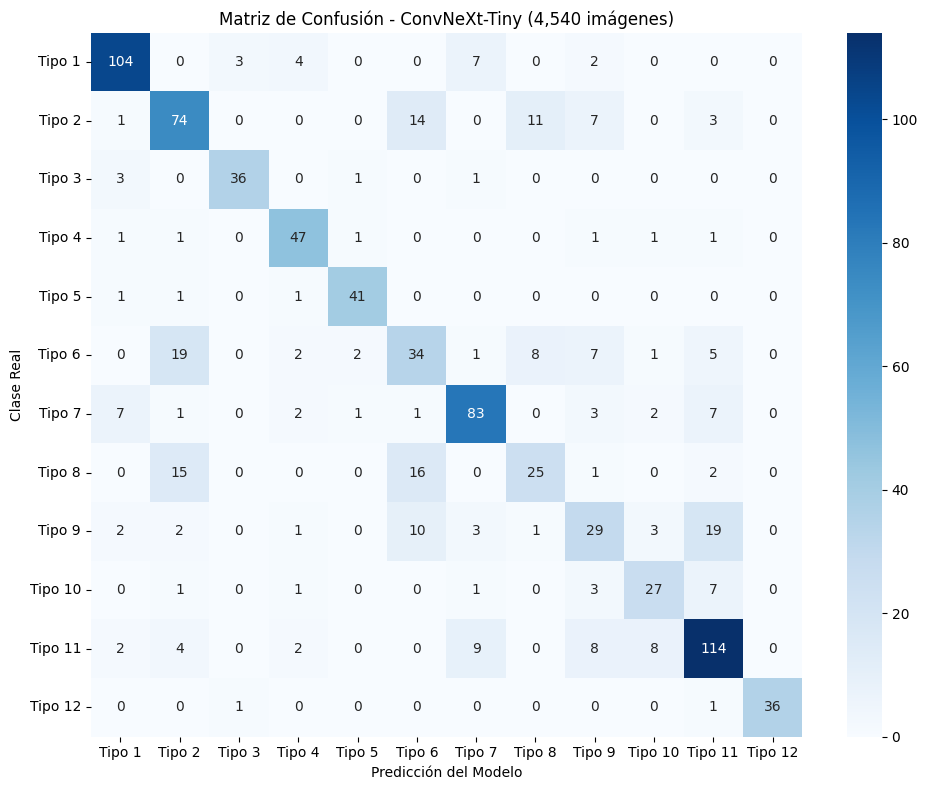

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

#  mejores pesos guardados de ConvNeXt-Tiny
model.load_state_dict(torch.load("convnext_tiny_clamm4540.pth"))
model.eval()

y_true = []
y_pred = []

print("Evaluando el mejor modelo ConvNeXt-Tiny guardado en el conjunto de validación...")

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Reporte de Clasificación
class_names = [f"Tipo {i+1}" for i in range(num_classes)]
print("\n--- REPORTE DE CLASIFICACIÓN POR CLASE (ConvNeXt-Tiny) ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

#  Matriz Plot
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusión - ConvNeXt-Tiny (4,540 imágenes)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.show()